In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, log_loss
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

file_path = 'dse_market_stress.csv'  # Update with the correct path
df = pd.read_csv(file_path)

# Features (all columns except the target)
X = df[['daily_return', 'high_low_spread', 'intraday_volatility', 'volume_change_pct', 'price_gap', 
        'rolling_5_day_volatility', 'rolling_10_day_momentum']]  # Add/modify with your feature list

# Convert features to float32 for efficiency
X = X.astype(np.float32)

# Target variable (market type)
y = df['market_type']  # Target variable (market type)

# Label encoding if necessary (market type classes: 0 = Normal, 1 = High Volatility, 2 = Crash)
le = LabelEncoder()
y = le.fit_transform(y)

# Convert target variable to float32 (if needed)
y = y.astype(np.float32)

In [2]:
# Check for inf and NaN values in the dataset
print("Number of Infinite values in each column:\n", np.isinf(X).sum())  # Check for infinite values
print("Number of NaN values in each column:\n", X.isna().sum())  # Check for NaN values

Number of Infinite values in each column:
 daily_return                    0
high_low_spread                 0
intraday_volatility          1153
volume_change_pct           20614
price_gap                       0
rolling_5_day_volatility        0
rolling_10_day_momentum         0
dtype: int64
Number of NaN values in each column:
 daily_return                0
high_low_spread             0
intraday_volatility         0
volume_change_pct           0
price_gap                   0
rolling_5_day_volatility    0
rolling_10_day_momentum     0
dtype: int64


In [3]:
# Replace inf with NaN
X.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values (or you can use imputation methods)
X.dropna(inplace=True)  # This removes rows with NaN values
y = y[X.index]  # Ensure the target variable aligns with the dropped rows

In [4]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],  # Narrowed down range for efficiency
    'max_depth': [3, 6, 10],  # Reduced depth range for faster computation
    'n_estimators': [100, 200, 300],  # Limited range for the number of trees
    'subsample': [0.7, 0.8, 1.0],  # Subsample to avoid overfitting with large data
    'colsample_bytree': [0.7, 0.8],  # Smaller sample of features to reduce training time
    'gamma': [0, 0.1, 0.2]  # Regularization term reduced
}

In [5]:

# Initialize the XGBoost model with dtype set to float32
xgb_model = xgb.XGBClassifier(eval_metric="mlogloss",
                              use_label_encoder=False,
                              dtype='float32')


from sklearn.model_selection import RandomizedSearchCV, ParameterSampler

# Calculate total number of fits (n_iter * cv)
total_fits = 5 * 3  # n_iter=5, cv=3

print(f"\nRandomizedSearchCV settings:")
print(f"n_iter: 5")
print(f"cv folds: 3")
print(f"Total fits: {total_fits}\n")
print("Starting Randomized Search...\n")

# Perform Randomized Search with fewer iterations (limit n_iter to 5 for faster results)
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=5,
    scoring='accuracy',
    cv=3,
    verbose=3,          # detailed progress printing like before
    random_state=42,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)

print("\nRandomized Search Completed!")
print("Best Hyperparameters from RandomizedSearchCV: ", random_search.best_params_)


RandomizedSearchCV settings:
n_iter: 5
cv folds: 3
Total fits: 15

Starting Randomized Search...

Fitting 3 folds for each of 5 candidates, totalling 15 fits


C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [23:23:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "dtype", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Randomized Search Completed!
Best Hyperparameters from RandomizedSearchCV:  {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}



Classification Report (XGBoost):
               precision    recall  f1-score   support

         0.0   0.997481  0.999691  0.998585    161997
         1.0   0.999186  0.992245  0.995704     51969
         2.0   0.861660  0.865079  0.863366       504

    accuracy                       0.997571    214470
   macro avg   0.952776  0.952339  0.952552    214470
weighted avg   0.997575  0.997571  0.997569    214470



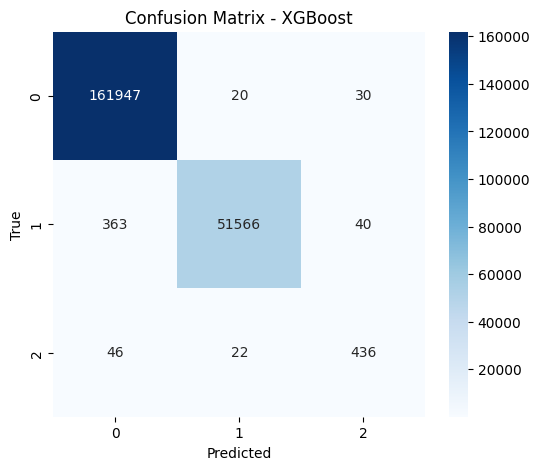

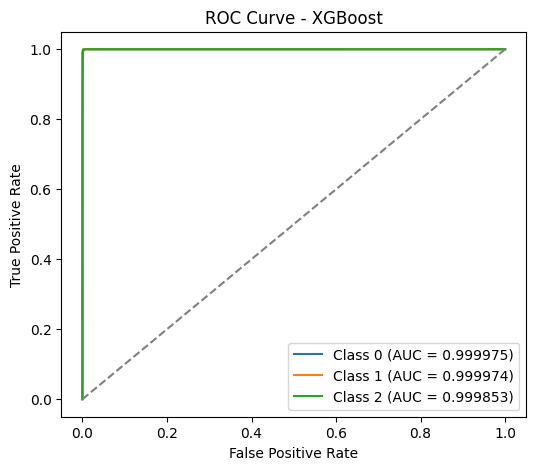

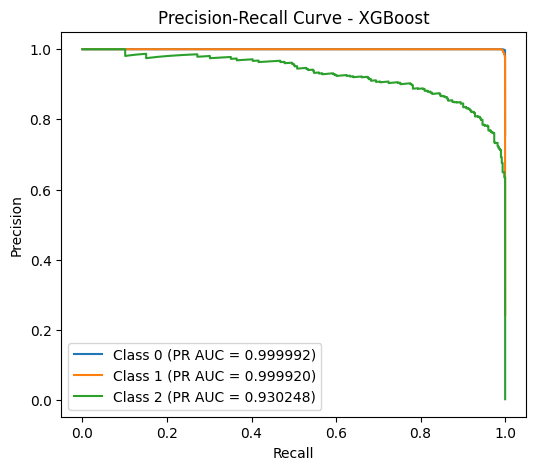

In [12]:

# Get the best model from RandomizedSearchCV
best_model = random_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Print Classification Report
print("\nClassification Report (XGBoost):\n", classification_report(y_test, y_pred, digits=6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve and AUC (for multiclass, one-vs-rest approach)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the target labels for multiclass classification (e.g., Normal, High Volatility, Crash)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_bin = best_model.predict_proba(X_test)

# Compute ROC curve and AUC for each class (one-vs-rest)
fpr, tpr, roc_auc = {}, {}, {}

for i in range(3):  # For each class (Normal, High Volatility, Crash)
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(6, 5))
for i in range(3):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.6f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve - XGBoost')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Precision-Recall Curve and PR AUC (one-vs-rest approach for multiclass)
from sklearn.metrics import precision_recall_curve, auc

precision, recall, pr_auc = {}, {}, {}

for i in range(3):  # For each class (Normal, High Volatility, Crash)
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
    pr_auc[i] = auc(recall[i], precision[i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(6, 5))
for i in range(3):
    plt.plot(recall[i], precision[i], label=f'Class {i} (PR AUC = {pr_auc[i]:.6f})')

plt.title('Precision-Recall Curve - XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.show()



In [ ]:

from sklearn.model_selection import cross_validate

# Get the best trained model
best_model = random_search.best_estimator_   # or grid_search.best_estimator_

# Define scoring metrics
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'neg_log_loss']

# Perform 3-fold cross validation
cv_results = cross_validate(best_model,
                            X_train,
                            y_train,
                            cv=3,
                            scoring=scoring,
                            return_train_score=False,
                            n_jobs=-1)

# Print Mean ± Std results
print("\n===== Cross Validation Report (3-Fold) =====\n")

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    
    if metric == 'neg_log_loss':
        scores = -scores  # convert back to positive log loss
    
    print(f"{metric.replace('neg_', '')}: {scores.mean():.4f} ± {scores.std():.4f}")


===== Cross Validation Report (3-Fold) =====

accuracy: 0.9977 ± 0.0001
precision_macro: 0.9470 ± 0.0023
recall_macro: 0.9510 ± 0.0062
f1_macro: 0.9490 ± 0.0039
log_loss: 0.0055 ± 0.0001


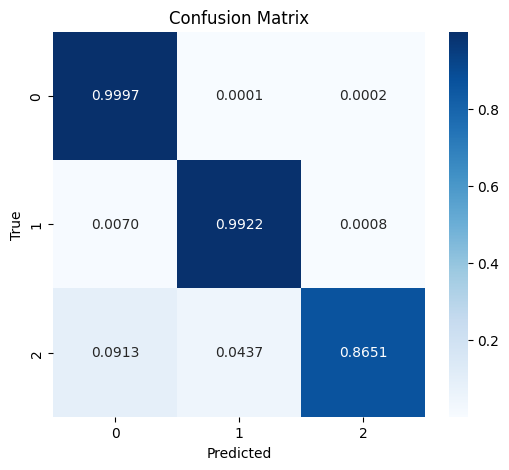

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Normalize the confusion matrix (by row sums)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot the normalized confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, fmt='.4f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:


import os
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_validate

# ---- Create Folder ----
save_dir = "xgboost_market_stress_model_package"
os.makedirs(save_dir, exist_ok=True)

# ---- Get Best Model ----
best_model = random_search.best_estimator_   # or grid_search.best_estimator_

# ---- Save Native XGBoost Model ----
best_model.save_model(os.path.join(save_dir, "model.json"))

# ---- Save Pickle Model ----
joblib.dump(best_model, os.path.join(save_dir, "model.pkl"))

# ---- Save Label Encoder ----
joblib.dump(le, os.path.join(save_dir, "label_encoder.pkl"))

# ---- Save Feature Names ----
feature_names = list(X.columns)
with open(os.path.join(save_dir, "features.json"), "w") as f:
    json.dump(feature_names, f, indent=4)

# ---- Save Best Hyperparameters ----
with open(os.path.join(save_dir, "best_params.json"), "w") as f:
    json.dump(best_model.get_params(), f, indent=4)

# ---- Generate & Save Cross-Validation Report ----
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'neg_log_loss']

cv_results = cross_validate(best_model,
                            X_train,
                            y_train,
                            cv=3,
                            scoring=scoring,
                            return_train_score=False,
                            n_jobs=-1)

cv_summary = {}

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    if metric == 'neg_log_loss':
        scores = -scores
        metric = 'log_loss'
    cv_summary[metric] = {
        "mean": float(np.mean(scores)),
        "std": float(np.std(scores))
    }

with open(os.path.join(save_dir, "cross_validation_report.json"), "w") as f:
    json.dump(cv_summary, f, indent=4)

# ---- Save Training Metadata ----
metadata = {
    "model_type": "XGBoost Classifier",
    "problem_type": "Multiclass Classification",
    "target_variable": "market_type",
    "num_features": len(feature_names),
    "num_samples": len(X),
    "cross_validation_folds": 3,
    "dataset_size": len(X)
}

with open(os.path.join(save_dir, "training_metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Complete model package saved successfully!")
print(f"📁 Folder created: {save_dir}")

✅ Complete model package saved successfully!
📁 Folder created: xgboost_market_stress_model_package
